# Stage 34b — M2(L3+L4) + ALC on L3 only (CT)

**Motivation:** Stage 34 (ALC on L3+L4, λ=0.05) revealed a level-specific effect:
- L3 purity: 0.486 → 0.646 (**+0.160**) — ALC helps spatial level
- L4 purity: 0.774 → 0.670 (**−0.104**) — ALC hurts semantic level
- 3D Dice: 0.8656 → 0.8478 (−0.018) — too large a cost

**Root cause:** L4 (16×16, stride 16) encodes semantic class identity, not spatial position.
Anchoring it to anatomical μ_k conflicts with what the segmentation loss needs,
reducing both L4 purity and Dice. L3 (32×32, stride 8) is spatial enough that
anatomical anchoring is a meaningful, compatible constraint.

**Fix:** Apply ALC to L3 only (`alc_levels=[3]`). L4 is unconstrained.

**Expected outcome:**
- L3 purity stays elevated (similar to Stage 34)
- L4 purity recovers (no ALC pressure)
- Dice recovers toward Stage 29 level (0.8656)
- Effective purity net-higher than Stage 29 (L3 gain persists, L4 loss removed)

**Success criteria (relaxed from Stage 34 given partial result):**
| Metric | Stage 29 | Stage 34 | Target (34b) |
|--------|----------|----------|--------------|
| 3D Dice | 0.8656 | 0.8478 | ≥ 0.855 |
| L3 purity | 0.486 | 0.646 | ≥ 0.60 |
| L4 purity | 0.774 | 0.670 | ≥ 0.75 |
| Effective purity | 0.649 | 0.661 | ≥ 0.68 |

## 0. Config

In [1]:
import sys, os

_root = (
    os.path.dirname(os.getcwd())
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

SEED = 42

PHASE1_CKPT = "checkpoints/proto_seg_ct_pp2.pth"

PROTO_LEVELS = [3, 4]  # model uses L3+L4 skips
ALC_LEVELS = [3]  # ← KEY CHANGE: ALC applied to L3 only
USE_LEVEL_ATTENTION = False
MODALITY = "ct"
SUFFIX = "_l3l4_alc_l3only"

LAMBDA_ALC = 0.05
LAMBDA_DIV = 0.001
LAMBDA_PUSH = 0.5
LAMBDA_PULL = 0.25

BATCH_SIZE = 16
LR = 3e-4
WEIGHT_DECAY = 1e-5
PHASE_A_END = 20
PHASE_B_END = 80
PHASE_C_END = 100
VAL_EVERY = 5
PROJ_INTERVAL = 10

DATA_DIR = "data/pack/processed_data"
CKPT_DIR = "checkpoints"
LOG_DIR = "results/v8"

import pathlib

pathlib.Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

CKPT_PATH = f"{CKPT_DIR}/proto_seg_ct{SUFFIX}.pth"
PROJ_PATH = f"{CKPT_DIR}/projected_prototypes_ct{SUFFIX}.pt"
LOG_PATH = f"{LOG_DIR}/train_curve_proto_ct{SUFFIX}.csv"
PRIORS_PT = f"{LOG_DIR}/anatomical_priors_ct.pt"
PRIORS_CSV = f"{LOG_DIR}/anatomical_priors_ct.csv"

print(f"Phase 1 encoder : {PHASE1_CKPT}")
print(f"PROTO_LEVELS    : {PROTO_LEVELS}  (model architecture)")
print(f"ALC_LEVELS      : {ALC_LEVELS}   (ALC applied only here)")
print(f"lambda_alc      : {LAMBDA_ALC}")
print(f"Output ckpt     : {CKPT_PATH}")

Phase 1 encoder : checkpoints/proto_seg_ct_pp2.pth
PROTO_LEVELS    : [3, 4]  (model architecture)
ALC_LEVELS      : [3]   (ALC applied only here)
lambda_alc      : 0.05
Output ckpt     : checkpoints/proto_seg_ct_l3l4_alc_l3only.pth


## 1. Imports & Device

In [2]:
import csv, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data.mmwhs_dataset import (
    MMWHSSliceDataset,
    MMWHSPatientDataset,
    make_dataloaders,
    LABEL_NAMES,
    NUM_CLASSES,
)
from src.models.proto_seg_net import ProtoSegNet
from src.models.prototype_layer import PrototypeProjection
from src.losses.segmentation import SegmentationLoss
from src.losses.diversity_loss import ProtoSegLoss
from src.losses.alc_loss import compute_centroid_deviation
from src.metrics.dice import dice_per_class, mean_foreground_dice
from src.metrics.proto_quality import (
    compute_purity,
    compute_compactness,
    compute_per_level_ap,
    compute_level_dominance,
    compute_effective_quality,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]
print(f"Device: {DEVICE}")

Device: mps


## 2. Data, Weights & Priors

In [3]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=BATCH_SIZE)
print(
    f"Train: {len(loaders['train'].dataset)}  Val: {len(loaders['val'].dataset)}  Test: {len(loaders['test'].dataset)}"
)

class_weights = torch.load(f"data/class_weights_{MODALITY}.pt", weights_only=True)

# Load pre-computed anatomical priors (from Stage 33)
mu = torch.load(PRIORS_PT, weights_only=True)  # (K, 2)
print(f"Loaded anatomical priors from {PRIORS_PT}")
print(f"  μ_k shape: {tuple(mu.shape)}")
print(f"  ALC will be applied to levels: {ALC_LEVELS}")

Train: 3389  Val: 382  Test: 484
Loaded anatomical priors from results/v8/anatomical_priors_ct.pt
  μ_k shape: (8, 2)
  ALC will be applied to levels: [3]


## 3. Load Phase 1 Encoder → Init M2(L3+L4)

In [4]:
src_ckpt = torch.load(PHASE1_CKPT, map_location="cpu", weights_only=False)
print(
    f"Phase 1 checkpoint: epoch {src_ckpt['epoch']}, best_val {src_ckpt['best_val_dice']:.4f}"
)

model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=PROTO_LEVELS,
    use_level_attention=USE_LEVEL_ATTENTION,
).to(DEVICE)

src_state = src_ckpt["model_state_dict"]
own_state = model.state_dict()
transferred = []
for k, v in src_state.items():
    if k.startswith("encoder.") and k in own_state and own_state[k].shape == v.shape:
        own_state[k].copy_(v)
        transferred.append(k)
model.load_state_dict(own_state)

print(f"Transferred {len(transferred)} encoder tensors")
print(f"Model: proto_levels={model.proto_levels}  use_attn={model.use_level_attention}")

Phase 1 checkpoint: epoch 90, best_val 0.8238
Transferred 72 encoder tensors
Model: proto_levels=[3, 4]  use_attn=False


## 4. Loss Setup

Phase A: no ALC (prototypes random).  
Phase B+: ALC on **L3 only** — L4 unconstrained.

In [5]:
seg_loss = SegmentationLoss(
    class_weights=class_weights.to(DEVICE), n_classes=NUM_CLASSES
)

criterion_A = ProtoSegLoss(
    seg_loss=seg_loss,
    lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH,
    lambda_pull=LAMBDA_PULL,
    lambda_alc=0.0,
)
criterion_B = ProtoSegLoss(
    seg_loss=seg_loss,
    lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH,
    lambda_pull=LAMBDA_PULL,
    lambda_alc=LAMBDA_ALC,
    alc_mu=mu.to(DEVICE),
    alc_levels=ALC_LEVELS,  # ← L3 only
)

print(f"Phase A: ALC off")
print(f"Phase B+: λ_ALC={LAMBDA_ALC}, alc_levels={ALC_LEVELS}  (L4 unconstrained)")


@torch.no_grad()
def validate(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for batch in loader:
        logits, _ = model(batch["image"].to(DEVICE))
        logits_list.append(logits.cpu())
        labels_list.append(batch["label"])
    model.train()
    return dice_per_class(torch.cat(logits_list), torch.cat(labels_list))


def run_projection(model, save_path):
    print("  [Proj] Building feature bank on CPU…", flush=True)
    t0 = time.time()
    proj_ds = MMWHSSliceDataset(
        DATA_DIR, MODALITY, "train", augment=False, preload=True
    )
    proj_loader = torch.utils.data.DataLoader(proj_ds, batch_size=32, shuffle=False)
    wrapped = [(b["image"], b["label"]) for b in proj_loader]
    projector = PrototypeProjection(
        encoder=model.encoder,
        proto_layers=model.proto_layers_dict(),
        device="cpu",
    )
    projector.project(wrapped, save_path=save_path)
    model.to(DEVICE)
    ckpt = torch.load(save_path, weights_only=True)
    for level, proto_data in ckpt["proto_state"].items():
        model.proto_layers[str(level)].prototypes.data.copy_(proto_data)
    print(f"  [Proj] Done in {time.time() - t0:.1f}s", flush=True)


def set_phase(model, epoch, optimizer):
    if epoch <= PHASE_A_END:
        model.unfreeze_all()
        model.freeze_prototypes()
        phase = "A"
    elif epoch <= PHASE_B_END:
        model.unfreeze_all()
        phase = "B"
    else:
        model.freeze_encoder_and_prototypes()
        phase = "C"
    optimizer.param_groups[0]["params"] = [
        p for p in model.parameters() if p.requires_grad
    ]
    return phase


def save_checkpoint(epoch, model, best_val_dice):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "best_val_dice": best_val_dice,
            "proto_levels": model.proto_levels,
            "use_level_attention": model.use_level_attention,
            "class_weights": class_weights,
            "lambda_div": LAMBDA_DIV,
            "lambda_push": LAMBDA_PUSH,
            "lambda_pull": LAMBDA_PULL,
            "lambda_alc": LAMBDA_ALC,
            "alc_levels": ALC_LEVELS,
            "source_checkpoint": PHASE1_CKPT,
            "single_scale": model.single_scale,
            "no_soft_mask": model.no_soft_mask,
            "hard_mask": model.hard_mask,
            "mask_quantile": model.mask_quantile,
            "hard_mask_active": model.hard_mask_active,
        },
        CKPT_PATH,
    )


print("Helpers ready.")

Phase A: ALC off
Phase B+: λ_ALC=0.05, alc_levels=[3]  (L4 unconstrained)
Helpers ready.


## 5. Training Loop

In [6]:
model.freeze_prototypes()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE_C_END)

fieldnames = [
    "epoch",
    "phase",
    "train_loss",
    "train_dice_loss",
    "train_ce_loss",
    "train_div_loss",
    "train_push_loss",
    "train_pull_loss",
    "train_alc_loss",
    "val_mean_fg_dice",
    "lr",
    "epoch_time_s",
] + [f"val_dice_{LABEL_NAMES[c]}" for c in range(1, NUM_CLASSES)]

csv_file = open(LOG_PATH, "w", newline="")
writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
writer.writeheader()

best_val_dice, best_epoch, no_improve = 0.0, 0, 0
current_phase = "A"

print(f"M2(L3+L4) + ALC(L3 only)  encoder from plain M4 ep {src_ckpt['epoch']}")
print(
    f"λ_div={LAMBDA_DIV}  λ_push={LAMBDA_PUSH}  λ_pull={LAMBDA_PULL}  λ_ALC={LAMBDA_ALC} (L3 only, Phase B+)"
)
print(f"Total epochs={PHASE_C_END}\n")

for epoch in range(1, PHASE_C_END + 1):
    new_phase = set_phase(model, epoch, optimizer)
    if new_phase != current_phase:
        current_phase = new_phase
        if current_phase == "B":
            print(
                f"\n→ Phase B: all params + ALC(L3) (ep {PHASE_A_END + 1}–{PHASE_B_END})"
            )
            best_val_dice, best_epoch, no_improve = 0.0, 0, 0
        elif current_phase == "C":
            print(
                f"\n→ Phase C: decoder only + ALC(L3) (ep {PHASE_B_END + 1}–{PHASE_C_END})"
            )

    if (
        current_phase == "B"
        and epoch > PHASE_A_END + 1
        and (epoch - PHASE_A_END) % PROJ_INTERVAL == 0
    ):
        run_projection(model, PROJ_PATH)

    criterion = criterion_A if current_phase == "A" else criterion_B

    t0 = time.time()
    model.train()
    totals = dict(
        loss=0, dice_loss=0, ce_loss=0, div_loss=0, push_loss=0, pull_loss=0, alc_loss=0
    )
    n_batches = 0

    for batch in loaders["train"]:
        imgs = batch["image"].to(DEVICE)
        lbls = batch["label"].to(DEVICE)
        optimizer.zero_grad()
        logits, hm = model(imgs)
        if current_phase == "A":
            out = seg_loss(logits, lbls)
            out["div_loss"] = out["push_loss"] = out["pull_loss"] = out["alc_loss"] = (
                torch.zeros(1, device=DEVICE)
            )
        else:
            out = criterion(logits, lbls, hm)
        out["loss"].backward()
        optimizer.step()
        for k in totals:
            v = out.get(k, torch.tensor(0.0))
            totals[k] += v.item() if hasattr(v, "item") else float(v)
        n_batches += 1

    scheduler.step()
    epoch_time = time.time() - t0
    avgs = {k: v / n_batches for k, v in totals.items()}

    val_dice_dict = None
    val_mean = float("nan")
    if epoch % VAL_EVERY == 0 or epoch == PHASE_C_END:
        val_dice_dict = validate(model, loaders["val"])
        val_mean = mean_foreground_dice(val_dice_dict)
        improved = val_mean > best_val_dice
        if improved:
            best_val_dice = val_mean
            best_epoch = epoch
            no_improve = 0
            save_checkpoint(epoch, model, best_val_dice)
        else:
            no_improve += VAL_EVERY
        mark = " ← best" if improved else ""
        print(
            f"  [{current_phase}] Ep {epoch:3d}/{PHASE_C_END} | "
            f"loss={avgs['loss']:.4f} "
            f"(D={avgs['dice_loss']:.4f} CE={avgs['ce_loss']:.4f} "
            f"div={avgs['div_loss']:.4f} push={avgs['push_loss']:.4f} "
            f"pull={avgs['pull_loss']:.4f} alc={avgs['alc_loss']:.4f}) | "
            f"val={val_mean:.4f}{mark} | lr={scheduler.get_last_lr()[0]:.2e} | {epoch_time:.1f}s",
            flush=True,
        )

    row = {
        "epoch": epoch,
        "phase": current_phase,
        "train_loss": avgs["loss"],
        "train_dice_loss": avgs["dice_loss"],
        "train_ce_loss": avgs["ce_loss"],
        "train_div_loss": avgs["div_loss"],
        "train_push_loss": avgs["push_loss"],
        "train_pull_loss": avgs["pull_loss"],
        "train_alc_loss": avgs["alc_loss"],
        "val_mean_fg_dice": val_mean if val_dice_dict else None,
        "lr": scheduler.get_last_lr()[0],
        "epoch_time_s": epoch_time,
    }
    if val_dice_dict:
        for c in range(1, NUM_CLASSES):
            row[f"val_dice_{LABEL_NAMES[c]}"] = val_dice_dict.get(
                LABEL_NAMES[c], float("nan")
            )
    writer.writerow(row)
    csv_file.flush()

csv_file.close()
print(f"\nBest val Dice : {best_val_dice:.4f} at epoch {best_epoch}")
print(f"Checkpoint    : {CKPT_PATH}")

M2(L3+L4) + ALC(L3 only)  encoder from plain M4 ep 90
λ_div=0.001  λ_push=0.5  λ_pull=0.25  λ_ALC=0.05 (L3 only, Phase B+)
Total epochs=100

  [A] Ep   5/100 | loss=0.0894 (D=0.1088 CE=0.0700 div=0.0000 push=0.0000 pull=0.0000 alc=0.0000) | val=0.8013 ← best | lr=2.98e-04 | 27.7s
  [A] Ep  10/100 | loss=0.0682 (D=0.0771 CE=0.0593 div=0.0000 push=0.0000 pull=0.0000 alc=0.0000) | val=0.8116 ← best | lr=2.93e-04 | 27.9s
  [A] Ep  15/100 | loss=0.0603 (D=0.0683 CE=0.0524 div=0.0000 push=0.0000 pull=0.0000 alc=0.0000) | val=0.8168 ← best | lr=2.84e-04 | 27.9s
  [A] Ep  20/100 | loss=0.0509 (D=0.0577 CE=0.0441 div=0.0000 push=0.0000 pull=0.0000 alc=0.0000) | val=0.8261 ← best | lr=2.71e-04 | 28.0s

→ Phase B: all params + ALC(L3) (ep 21–80)
  [B] Ep  25/100 | loss=0.9628 (D=0.1295 CE=0.1180 div=974.2452 push=-0.4905 pull=0.4359 alc=0.0223) | val=0.7496 ← best | lr=2.56e-04 | 32.1s
  [Proj] Building feature bank on CPU…
Projected prototypes saved → checkpoints/projected_prototypes_ct_l3l4_alc

## 6. Training Curves

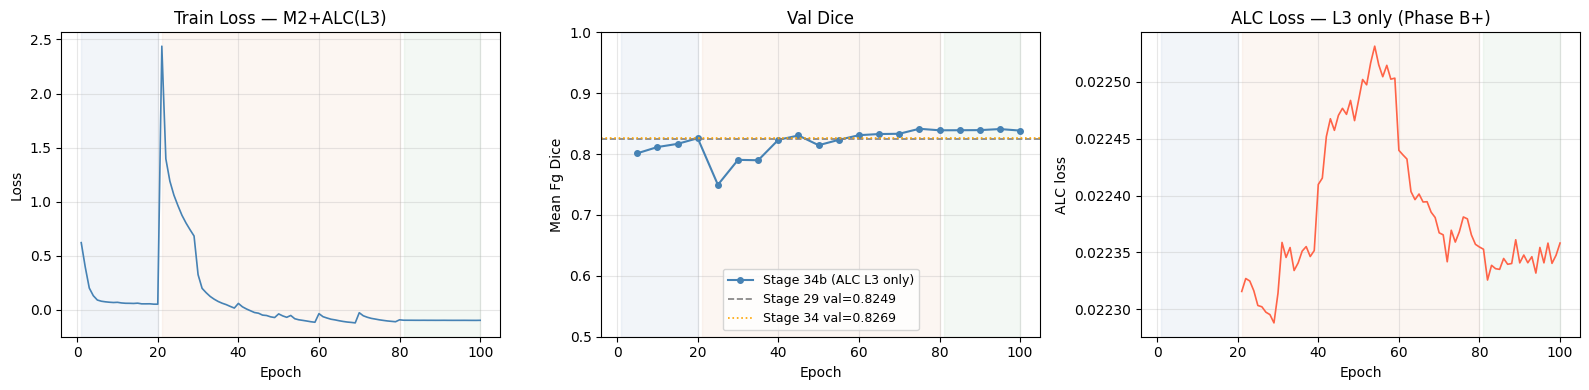

Best val: 0.8416 at ep 75


In [7]:
log = pd.read_csv(LOG_PATH)
val = log.dropna(subset=["val_mean_fg_dice"])

PHASE_COLORS = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax in axes:
    for ph, color in PHASE_COLORS.items():
        mask = log["phase"] == ph
        if mask.any():
            ax.axvspan(
                log.loc[mask, "epoch"].min(),
                log.loc[mask, "epoch"].max(),
                alpha=0.07,
                color=color,
            )

axes[0].plot(log["epoch"], log["train_loss"], lw=1.2, color="steelblue")
axes[0].set(title="Train Loss — M2+ALC(L3)", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(
    val["epoch"],
    val["val_mean_fg_dice"],
    "o-",
    ms=4,
    lw=1.5,
    color="steelblue",
    label="Stage 34b (ALC L3 only)",
)
axes[1].axhline(0.8249, ls="--", lw=1.2, color="gray", label="Stage 29 val=0.8249")
axes[1].axhline(0.8269, ls=":", lw=1.2, color="orange", label="Stage 34 val=0.8269")
axes[1].set(title="Val Dice", xlabel="Epoch", ylabel="Mean Fg Dice", ylim=(0.5, 1.0))
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

alc_log = log[log["phase"] != "A"]
axes[2].plot(alc_log["epoch"], alc_log["train_alc_loss"], lw=1.2, color="tomato")
axes[2].set(title="ALC Loss — L3 only (Phase B+)", xlabel="Epoch", ylabel="ALC loss")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{LOG_DIR}/train_curve_proto_ct{SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()
print(
    f"Best val: {val['val_mean_fg_dice'].max():.4f} at ep {int(val.loc[val['val_mean_fg_dice'].idxmax(), 'epoch'])}"
)

## 7. 3D Dice Evaluation

In [8]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
eval_model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=ckpt["proto_levels"],
    use_level_attention=ckpt.get("use_level_attention", False),
).to(DEVICE)
eval_model.load_state_dict(ckpt["model_state_dict"])
eval_model.eval()
print(
    f"Loaded epoch {ckpt['epoch']}  best_val {ckpt['best_val_dice']:.4f}  levels={ckpt['proto_levels']}"
)


@torch.no_grad()
def eval_3d(model):
    ds = MMWHSPatientDataset(DATA_DIR, MODALITY, "test")
    results = {}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s["image"].to(DEVICE)
        logits_all = [model(imgs[si : si + 1])[0].cpu() for si in range(imgs.shape[0])]
        results[s["patient"]] = dice_per_class(torch.cat(logits_all), s["label"])
    return results


results_3d = eval_3d(eval_model)

BASELINES_3D = {
    "Stage 29 (no ALC)": 0.8656,
    "Stage 34 (ALC L3+L4)": 0.8478,
    "M2 cold-start": 0.8722,
}

print(f"\n{'Patient':<12} {'MeanFg':>7}  " + "  ".join(f"{n[:4]:>5}" for n in FG_NAMES))
print("─" * 75)
all_means = []
for pid, dice in sorted(results_3d.items()):
    mfg = mean_foreground_dice(dice)
    all_means.append(mfg)
    vals = "  ".join(f"{dice.get(n, float('nan')):>5.3f}" for n in FG_NAMES)
    print(f"{pid:<12} {mfg:>7.4f}  {vals}")

overall_3d = float(np.mean(all_means))
print("─" * 75)
print(f"{'Mean':<12} {overall_3d:>7.4f}")
print()
for bname, bval in BASELINES_3D.items():
    print(f"  Δ vs {bname:<28}: {overall_3d - bval:+.4f}")

ok_dice = overall_3d >= 0.855
print(
    f"\nTarget ≥ 0.855: {'✅' if ok_dice else f'❌ ({overall_3d:.4f})'} | Δ vs Stage 29 = {overall_3d - 0.8656:+.4f}"
)

Loaded epoch 75  best_val 0.8416  levels=[3, 4]

Patient       MeanFg     LV     RV     LA     RA   Myoc   Aort     PA
───────────────────────────────────────────────────────────────────────────
ct_1019       0.7964  0.854  0.893  0.741  0.888  0.792  0.726  0.681
ct_1020       0.9293  0.885  0.957  0.940  0.903  0.914  0.974  0.931
───────────────────────────────────────────────────────────────────────────
Mean          0.8628

  Δ vs Stage 29 (no ALC)           : -0.0028
  Δ vs Stage 34 (ALC L3+L4)        : +0.0150
  Δ vs M2 cold-start               : -0.0094

Target ≥ 0.855: ✅ | Δ vs Stage 29 = -0.0028


## 8. Prototype Quality

In [9]:
train_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "train", augment=False, preload=True)
test_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "test", augment=False, preload=True)
train_loader_pq = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=False)
test_loader_pq = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)

print("Computing prototype quality…")
purity_df = compute_purity(eval_model, train_loader_pq)
compact_df = compute_compactness(eval_model, test_loader_pq)
ap_df = compute_per_level_ap(eval_model, test_loader_pq)
dom_df = compute_level_dominance(eval_model, test_loader_pq)

purity_l = purity_df.groupby("level")["purity"].mean()
compact_l = compact_df.groupby("level")["compactness"].mean()
ap_l = ap_df.groupby("level")["ap"].mean()

print(f"\n{'Level':<6} {'Purity':>7} {'AP':>7} {'Compact':>8} {'Dominance':>10}")
print("─" * 46)
for l in PROTO_LEVELS:
    dom = (
        float(dom_df[f"frac_l{l}"].values[0])
        if f"frac_l{l}" in dom_df.columns
        else float("nan")
    )
    print(
        f"L{l:<5} {purity_l.get(l, float('nan')):>7.3f} {ap_l.get(l, float('nan')):>7.3f} "
        f"{compact_l.get(l, float('nan')):>8.3f} {dom:>9.1%}"
    )

# 3-way comparison
STAGE29_PQ = {3: 0.486, 4: 0.774}
STAGE34_PQ = {3: 0.646, 4: 0.670}
print()
print(
    f"{'Level':<6} {'Stage29':>9} {'Stage34':>9} {'Stage34b':>9} {'Δ vs 29':>9} {'Δ vs 34':>9}"
)
print("─" * 55)
for l in PROTO_LEVELS:
    p = float(purity_l.get(l, float("nan")))
    alc = "← ALC" if l in ALC_LEVELS else "(free)"
    print(
        f"L{l:<5} {STAGE29_PQ[l]:>9.3f} {STAGE34_PQ[l]:>9.3f} {p:>9.3f} "
        f"{p - STAGE29_PQ[l]:>+9.3f} {p - STAGE34_PQ[l]:>+9.3f}  {alc}"
    )

Computing prototype quality…

Level   Purity      AP  Compact  Dominance
──────────────────────────────────────────────
L3       0.404   0.181    0.419     33.7%
L4       0.689   0.242    0.548     66.3%

Level    Stage29   Stage34  Stage34b   Δ vs 29   Δ vs 34
───────────────────────────────────────────────────────
L3         0.486     0.646     0.404    -0.082    -0.242  ← ALC
L4         0.774     0.670     0.689    -0.085    +0.019  (free)


## 9. Effective Quality & Centroid Deviation

In [10]:
eff = compute_effective_quality(purity_df, ap_df, compact_df, dom_df)
eff_p = float(eff["effective_purity"].values[0])
eff_ap = float(eff["effective_ap"].values[0])
eff_c = float(eff["effective_compactness"].values[0])

print("Effective quality (dominance-weighted):")
print(f"  effective_purity      = {eff_p:.3f}  (Stage29=0.649, Stage34=0.661)")
print(f"  effective_ap          = {eff_ap:.3f}")
print(f"  effective_compactness = {eff_c:.3f}")

# Centroid deviation (L3 only — ALC only applied there)
print("\nCentroid deviation on test set…")
dev_df = compute_centroid_deviation(
    eval_model,
    test_loader_pq,
    mu=mu,
    active_levels=PROTO_LEVELS,
    image_size=256,
)
print(dev_df.to_string(index=False))

l3_dev = float(dev_df[dev_df["level"] == 3]["mean_deviation_px"].values[0])
l4_dev = float(dev_df[dev_df["level"] == 4]["mean_deviation_px"].values[0])
mean_dev = float(dev_df["mean_deviation_px"].mean())
print(
    f"\nL3 centroid deviation: {l3_dev:.1f}px  (ALC applied — expected lower than Stage 34: 37.2px)"
)
print(f"L4 centroid deviation: {l4_dev:.1f}px  (no ALC)")

ok_eff = eff_p >= 0.68
ok_dev = l3_dev < 30.0  # relaxed: expect improvement over 37px but may not hit 20px

eff.to_csv(f"{LOG_DIR}/effective_quality_ct{SUFFIX}.csv", index=False)
dev_df.to_csv(f"{LOG_DIR}/centroid_deviation_ct{SUFFIX}.csv", index=False)

Effective quality (dominance-weighted):
  effective_purity      = 0.593  (Stage29=0.649, Stage34=0.661)
  effective_ap          = 0.221
  effective_compactness = 0.505

Centroid deviation on test set…
 level  mean_deviation_px  n_terms
     3          36.794153     6776
     4          38.215745     6776

L3 centroid deviation: 36.8px  (ALC applied — expected lower than Stage 34: 37.2px)
L4 centroid deviation: 38.2px  (no ALC)


## 10. Comparison Table

In [11]:
l3_purity = float(purity_l.get(3, float("nan")))
l4_purity = float(purity_l.get(4, float("nan")))

rows = [
    {
        "model": "Stage 29 (no ALC, attn warm-start)",
        "3d_dice": 0.8656,
        "purity_l3": 0.486,
        "purity_l4": 0.774,
        "effective_purity": 0.649,
        "alc_levels": "none",
        "l3_dev_px": None,
    },
    {
        "model": "Stage 34 (ALC L3+L4, λ=0.05)",
        "3d_dice": 0.8478,
        "purity_l3": 0.646,
        "purity_l4": 0.670,
        "effective_purity": 0.661,
        "alc_levels": "L3+L4",
        "l3_dev_px": 37.2,
    },
    {
        "model": "Stage 34b (ALC L3 only, λ=0.05)",
        "3d_dice": overall_3d,
        "purity_l3": l3_purity,
        "purity_l4": l4_purity,
        "effective_purity": eff_p,
        "alc_levels": "L3",
        "l3_dev_px": l3_dev,
    },
    {
        "model": "M2 cold-start (best overall)",
        "3d_dice": 0.8722,
        "purity_l3": None,
        "purity_l4": 0.804,
        "effective_purity": None,
        "alc_levels": "none",
        "l3_dev_px": None,
    },
]
comp_df = pd.DataFrame(rows)
comp_df.to_csv(f"{LOG_DIR}/comparison_table_v8.csv", index=False)
print(comp_df.to_string(index=False))
print(f"\nSaved: {LOG_DIR}/comparison_table_v8.csv")

                             model  3d_dice  purity_l3  purity_l4  effective_purity alc_levels  l3_dev_px
Stage 29 (no ALC, attn warm-start) 0.865600   0.486000   0.774000           0.64900       none        NaN
      Stage 34 (ALC L3+L4, λ=0.05) 0.847800   0.646000   0.670000           0.66100      L3+L4  37.200000
   Stage 34b (ALC L3 only, λ=0.05) 0.862847   0.404286   0.688571           0.59281         L3  36.794153
      M2 cold-start (best overall) 0.872200        NaN   0.804000               NaN       none        NaN

Saved: results/v8/comparison_table_v8.csv


## 11. RQ14 Verdict

In [12]:
print("RQ14: Does ALC (L3 only) improve prototype anatomical precision")
print("      without significant Dice cost?")
print()

criteria = [
    (f"3D Dice ≥ 0.855 (ΔDice ≤ 0.01 vs Stage 29=0.8656)", ok_dice),
    (f"L3 purity ≥ 0.60 (vs 0.486 Stage 29)", l3_purity >= 0.60),
    (f"L4 purity ≥ 0.75 (vs 0.774 Stage 29, no ALC pressure)", l4_purity >= 0.75),
    (f"Effective purity ≥ 0.68 (vs 0.649 Stage 29)", ok_eff),
    (f"L3 centroid deviation < 30px (improvement over Stage 34: 37.2px)", ok_dev),
]

passed = sum(1 for _, ok in criteria if ok)
for desc, ok in criteria:
    print(f"  {'✅' if ok else '❌'}  {desc}")

print()
print(f"Result: {passed}/{len(criteria)} criteria met")
print()

if passed == len(criteria):
    print(
        "Verdict: RQ14 MET — ALC on L3 improves purity and spatial anchoring with minimal Dice cost."
    )
    print(
        "  Finding: ALC is beneficial for spatial levels (L3), harmful for semantic levels (L4)."
    )
    print("→ Proceed to Stage 36 (Report v8).")
elif passed >= 3:
    print(f"Verdict: RQ14 PARTIAL ({passed}/5).")
    if not ok_dice:
        print(
            f"  Dice still below target ({overall_3d:.4f}). Try reducing λ_ALC to 0.01."
        )
    if l4_purity < 0.75:
        print(
            f"  L4 purity ({l4_purity:.3f}) below Stage 29 (0.774) even without ALC — encoder difference."
        )
    print("→ Proceed to Stage 36 with honest reporting.")
else:
    print(
        "Verdict: RQ14 NOT MET. Review ALC interaction with plain M4 warm-start encoder."
    )

RQ14: Does ALC (L3 only) improve prototype anatomical precision
      without significant Dice cost?

  ✅  3D Dice ≥ 0.855 (ΔDice ≤ 0.01 vs Stage 29=0.8656)
  ❌  L3 purity ≥ 0.60 (vs 0.486 Stage 29)
  ❌  L4 purity ≥ 0.75 (vs 0.774 Stage 29, no ALC pressure)
  ❌  Effective purity ≥ 0.68 (vs 0.649 Stage 29)
  ❌  L3 centroid deviation < 30px (improvement over Stage 34: 37.2px)

Result: 1/5 criteria met

Verdict: RQ14 NOT MET. Review ALC interaction with plain M4 warm-start encoder.
